In [1]:
!pip install -q tensorflow scikit-learn seaborn

In [2]:
import os
import json
import random
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Extracting outer zip...
✅ Done!
⏳ Extracting inner zip...
✅ Done!

📊 Total Classes: 32
📸 Total Images:  54049
📈 Max: 2114 → ain
📉 Min: 1293 → yaa
⚠️  Imbalance ratio: 1.6x

 Class  Count
  ain   2114
ghain   1977
   fa   1955
 saad   1895
  taa   1838
 laam   1832
  nun   1819
   ta   1816
 toot   1791
   bb   1791
 kaaf   1774
 thaa   1766
 meem   1765
   la   1746
  dha   1723
   ya   1722
 gaaf   1705
aleff   1672
 dhad   1670
   ra   1659
 seen   1638
  dal   1634
 khaa   1607
   ha   1592
 thal   1582
 jeem   1552
  haa   1526
sheen   1507
  zay   1374
  waw   1371
   al   1343
  yaa   1293


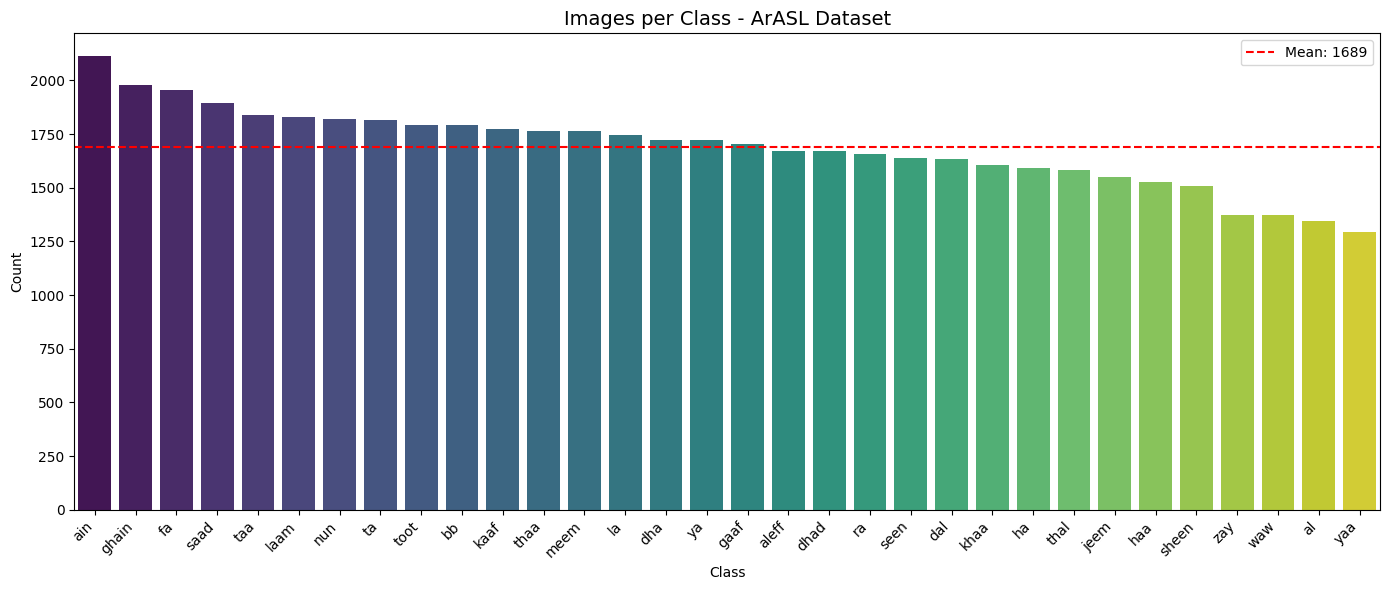

In [3]:
from google.colab import drive
import zipfile, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define paths
OUTER_ZIP = '/content/drive/MyDrive/DSAI_Final_Project/y7pckrw6z2-1.zip'
EXTRACT_1 = '/content/outer'
INNER_ZIP  = '/content/outer/ArASL_Database_54K_Final.zip'
DATASET    = '/content/ArASL_Dataset/ArASL_Database_54K_Final'

# 3. Extract the outer zip file
print("⏳ Extracting outer zip...")
with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
    z.extractall(EXTRACT_1)
print("✅ Done!")

# 4. Extract the inner zip file
print("⏳ Extracting inner zip...")
with zipfile.ZipFile(INNER_ZIP, 'r') as z:
    z.extractall('/content/ArASL_Dataset')
print("✅ Done!")

# 5. Compute dataset statistics while ignoring non-class folders
VALID_CLASSES = {
    'ain','al','aleff','bb','dal','dha','dhad','fa','gaaf','ghain',
    'ha','haa','jeem','kaaf','khaa','la','laam','meem','nun','ra',
    'saad','seen','sheen','ta','taa','thaa','thal','toot','waw','ya','yaa','zay'
}

class_counts = {}
for cls in sorted(os.listdir(DATASET)):
    cls_path = os.path.join(DATASET, cls)
    if os.path.isdir(cls_path) and cls in VALID_CLASSES:
        class_counts[cls] = len(os.listdir(cls_path))

stats = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
stats = stats.sort_values('Count', ascending=False)

print(f"\n📊 Total Classes: {len(stats)}")
print(f"📸 Total Images:  {stats['Count'].sum()}")
print(f"📈 Max: {stats['Count'].max()} → {stats.iloc[0]['Class']}")
print(f"📉 Min: {stats['Count'].min()} → {stats.iloc[-1]['Class']}")
print(f"⚠️  Imbalance ratio: {stats['Count'].max() / stats['Count'].min():.1f}x")
print("\n", stats.to_string(index=False))

# 6. Plot class distribution
plt.figure(figsize=(14, 6))
sns.barplot(data=stats, x='Class', y='Count', hue='Class', legend=False, palette='viridis')
plt.axhline(stats['Count'].mean(), color='red', linestyle='--',
            label=f"Mean: {stats['Count'].mean():.0f}")
plt.title('Images per Class - ArASL Dataset', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import os, random, shutil

DATASET = '/content/ArASL_Dataset/ArASL_Database_54K_Final'

WORK_DIR = '/content/arsl_project'
SPLIT_DIR = os.path.join(WORK_DIR, 'splits')

train_dir = os.path.join(SPLIT_DIR, 'train')
val_dir   = os.path.join(SPLIT_DIR, 'val')
test_dir  = os.path.join(SPLIT_DIR, 'test')

VALID_CLASSES = [
    'ain','al','aleff','bb','dal','dha','dhad','fa','gaaf','ghain',
    'ha','haa','jeem','kaaf','khaa','la','laam','meem','nun','ra',
    'saad','seen','sheen','ta','taa','thaa','thal','toot','waw','ya','yaa','zay'
]

for d in [train_dir, val_dir, test_dir]:
    for c in VALID_CLASSES:
        os.makedirs(os.path.join(d, c), exist_ok=True)

IMAGE_EXTS = ('.jpg','.jpeg','.png')
random.seed(42)

print("⏳ Splitting dataset...")

for cls in VALID_CLASSES:
    src = os.path.join(DATASET, cls)
    if not os.path.exists(src):
        continue

    files = [f for f in os.listdir(src) if f.endswith(IMAGE_EXTS)]
    random.shuffle(files)

    n = len(files)
    t1 = int(0.8*n)
    t2 = int(0.9*n)

    splits = {
        train_dir: files[:t1],
        val_dir: files[t1:t2],
        test_dir: files[t2:]
    }

    for sp, fs in splits.items():
        for f in fs:
            shutil.copyfile(
                os.path.join(src, f),
                os.path.join(sp, cls, f)
            )

print("✅ Dataset split done")

⏳ Splitting dataset...
✅ Dataset split done


In [5]:
import tensorflow as tf

IMG_SIZE = 160   # 🔥 مهم للهاتف
BATCH_SIZE = 32

preprocess = tf.keras.applications.efficientnet.preprocess_input

train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess
)

val_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

NUM_CLASSES = len(VALID_CLASSES)

Found 34161 images belonging to 32 classes.
Found 4270 images belonging to 32 classes.


In [6]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)  # 🔥 خفيف للموبايل
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,090,563 (15.60 MB)

 Trainable params: 40,992 (160.12 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.7980 - loss: 0.8050 - val_accuracy: 0.9478 - val_loss: 0.2734
Epoch 2/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.9307 - loss: 0.2938 - val_accuracy: 0.9789 - val_loss: 0.1475
Epoch 3/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9519 - loss: 0.2036 - val_accuracy: 0.9827 - val_loss: 0.1008
Epoch 4/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9602 - loss: 0.1623 - val_accuracy: 0.9881 - val_loss: 0.0776
Epoch 5/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9671 - loss: 0.1347 - val_accuracy: 0.9883 - val_loss: 0.0655
Epoch 6/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9686 - loss: 0.1226 - val_accuracy: 0.9890 - val_loss: 0.0587
Epoch 7/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9691 - loss: 0.1121 - val_accuracy: 0.9883 - val_loss: 0.0563
Epoch 8/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9715 -

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# --- Fine-tuning setup ---
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Re-compile with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 1. Define callbacks specifically for fine-tuning
fine_tune_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,                # Stop if no improvement for 3 epochs
        restore_best_weights=True  # Crucial: gets you the best version of the model
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-7                # Allow learning rate to drop even further
    )
]

# 2. Run the fine-tuning fit
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,                     # You can increase this; EarlyStopping will handle it
    callbacks=fine_tune_callbacks  # <-- Add them here
)

Epoch 1/15
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 71s 43ms/step - accuracy: 0.9541 - loss: 0.1446 - val_accuracy: 0.9934 - val_loss: 0.0236 - learning_rate: 1.0000e-04
Epoch 2/15
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9823 - loss: 0.0562 - val_accuracy: 0.9944 - val_loss: 0.0216 - learning_rate: 1.0000e-04
Epoch 3/15
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9880 - loss: 0.0387 - val_accuracy: 0.9948 - val_loss: 0.0237 - learning_rate: 1.0000e-04
Epoch 4/15
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9912 - loss: 0.0286 - val_accuracy: 0.9948 - val_loss: 0.0212 - learning_rate: 1.0000e-04
Epoch 5/15
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9924 - loss: 0.0233 - val_accuracy: 0.9953 - val_loss: 0.0212 - learning_rate: 1.0000e-04
Epoch 6/15
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.9953 - val_loss: 0.0209 - learning_rate: 1.0000e-04
Epoch 7/15
1068/1068 ━━━━━━━━━━━━━━━━━━━

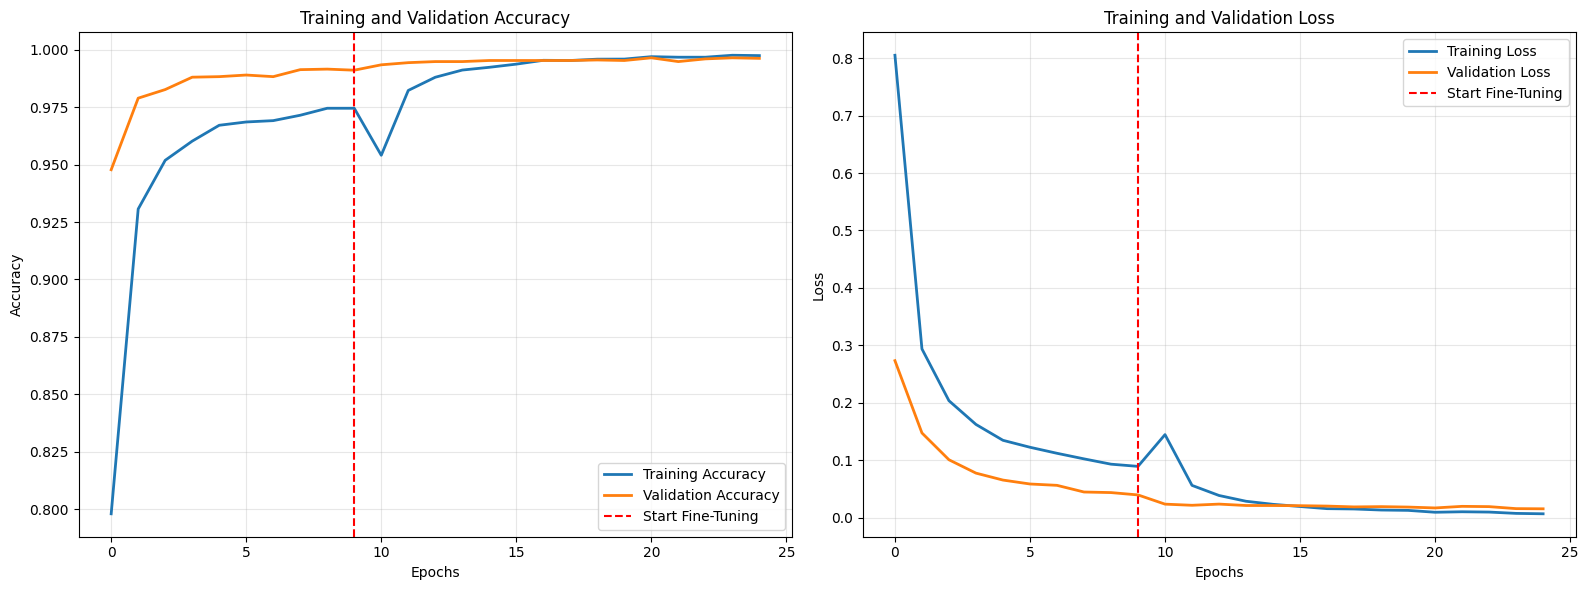

In [9]:
import matplotlib.pyplot as plt

# 1. Extract the metrics from both training phases
acc = history.history['accuracy'] + history2.history['accuracy']
val_acc = history.history['val_accuracy'] + history2.history['val_accuracy']

loss = history.history['loss'] + history2.history['loss']
val_loss = history.history['val_loss'] + history2.history['val_loss']

# 2. Get the number of epochs for the first phase to draw the vertical line
initial_epochs = len(history.history['accuracy'])

# 3. Create the plots
plt.figure(figsize=(16, 6))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', linewidth=2)

# Draw a vertical line where fine-tuning starts
plt.axvline(x=initial_epochs - 1, color='red', linestyle='--', label='Start Fine-Tuning')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)

# Draw a vertical line where fine-tuning starts
plt.axvline(x=initial_epochs - 1, color='red', linestyle='--', label='Start Fine-Tuning')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 4. Display the graphs
plt.tight_layout()
plt.show()

In [10]:
test_data = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
).flow_from_directory(
    test_dir,          #
    target_size=(160, 160),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Found 4287 images belonging to 32 classes.


In [11]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("GPUs:", tf.config.list_physical_devices('GPU'))

y_true = []
y_pred = []

# عدد الخطوات (مهم جدًا)
steps = test_data.samples // test_data.batch_size
if test_data.samples % test_data.batch_size != 0:
    steps += 1

# 🔥 loop مضبوط
for i in range(steps):
    images, labels = next(test_data)

    images = tf.cast(images, tf.float32)

    preds = model(images, training=False)
    preds = tf.argmax(preds, axis=1)

    y_pred.extend(preds.numpy())
    y_true.extend(labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 📊 النتائج
print("\n📊 CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=VALID_CLASSES))

cm = confusion_matrix(y_true, y_pred)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

📊 CLASSIFICATION REPORT

              precision    recall  f1-score   support

         ain       1.00      1.00      1.00       174
          al       1.00      1.00      1.00       121
       aleff       1.00      1.00      1.00       127
          bb       1.00      1.00      1.00       135
         dal       1.00      1.00      1.00       125
         dha       0.99      0.97      0.98       138
        dhad       1.00      1.00      1.00       132
          fa       1.00      1.00      1.00       160
        gaaf       1.00      1.00      1.00       136
       ghain       1.00      1.00      1.00       161
          ha       1.00      1.00      1.00       126
         haa       0.99      1.00      1.00       116
        jeem       1.00      1.00      1.00       117
        kaaf       1.00      0.99      1.00       141
        khaa       1.00      1.00      1.00       124
          la       1.00      1.00   

In [13]:
MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

keras_path = os.path.join(MODEL_DIR, "arasl_lite.keras")
model.save(keras_path)

print("✅ Saved:", keras_path)

✅ Saved: /content/models/arasl_lite.keras


In [14]:
import tensorflow as tf
import numpy as np

# ============================================================
# 📦 Representative Dataset FIX (مهم جداً)
# ============================================================

def representative_data_gen():
    # ناخذ دفعات من generator بطريقة صحيحة
    for i in range(50):
        images, _ = train_data[i]
        for img in images:
            img = np.expand_dims(img, axis=0)
            yield [img.astype(np.float32)]

# ============================================================
# 📦 TFLite Converter (Mobile INT8)
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 🔥 أهم خطوة للأداء على الهاتف
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# INT8 quantization
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

print("⏳ Converting to INT8 TFLite (Mobile optimized)...")

tflite_model = converter.convert()

# ============================================================
# 💾 Save model
# ============================================================

tflite_path = '/content/arasl_mobile_int8.tflite'

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print("✅ Saved:", tflite_path)
print("🚀 Ready for Android / Real-time inference")

⏳ Converting to INT8 TFLite (Mobile optimized)...
Saved artifact at '/tmp/tmpd6yr5pqw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 32), dtype=tf.float32, name=None)
Captures:
  135760227819856: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135760227825424: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135760320166608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135760320166416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135760320163728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135760320167184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135760320156240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135760320167760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135760226977552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13576022697

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Saved: /content/arasl_mobile_int8.tflite
🚀 Ready for Android / Real-time inference


In [15]:
import os
print(f"TFLite Model Size: {os.path.getsize(tflite_path) / 1024 / 1024:.2f} MB")

TFLite Model Size: 4.72 MB


In [16]:
import time
import numpy as np
import os

# 1. Load the TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Grab a real batch from your test_data generator
test_images, test_labels = next(test_data)

# Take the first image and ensure it has the batch dimension (1, 160, 160, 3)
input_data = np.expand_dims(test_images[0], axis=0)

# 3. 🎯 THE FIX: Match the expected UINT8 type
# Most ArASL models expect pixels in 0-255 range for UINT8
if input_details[0]['dtype'] == np.uint8:
    # If your generator provides normalized images (0-1), multiply by 255
    if input_data.max() <= 1.0:
        input_data = input_data * 255.0
    input_data = input_data.astype(np.uint8)

# 4. Measure Inference Time
start_time = time.time()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
end_time = time.time()

# 5. Get Results
output_data = interpreter.get_tensor(output_details[0]['index'])
prediction = np.argmax(output_data)

# Calculate confidence
# For UINT8/INT8, we convert the raw integer score back to a probability
if output_details[0]['dtype'] == np.uint8 or output_details[0]['dtype'] == np.int8:
    output_scale, output_zero_point = output_details[0]['quantization']
    confidence = (np.max(output_data) - output_zero_point) * output_scale
else:
    confidence = np.max(output_data)

# ============================================================
# 📊 Results Summary
# ============================================================
file_size = os.path.getsize(tflite_path) / 1024 / 1024
inference_ms = (end_time - start_time) * 1000

print(f"--- 📊 ArASL Model Benchmark ---")
print(f"📦 Model Size: {file_size:.2f} MB")
print(f"⚡ Inference Time: {inference_ms:.2f} ms")
print(f"🎯 Confidence: {confidence:.2%}")
print(f"🔢 Predicted Class index: {prediction}")

--- 📊 ArASL Model Benchmark ---
📦 Model Size: 4.72 MB
⚡ Inference Time: 9.20 ms
🎯 Confidence: 99.61%
🔢 Predicted Class index: 0


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [23]:
import os, json
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

SAVE_DIR = '/content/drive/MyDrive/DSAI_Final_Project'
os.makedirs(SAVE_DIR, exist_ok=True)

# احفظ الموديل
model.save(os.path.join(SAVE_DIR, 'arasl_lite.keras'))

# احفظ أسماء الفئات بالترتيب الصحيح (مهم جداً!)
class_names = [k for k, v in sorted(train_data.class_indices.items(), key=lambda x: x[1])]
with open(os.path.join(SAVE_DIR, 'class_names.json'), 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False)

print("✅ Saved model + class_names")
print("Classes:", class_names)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved model + class_names
Classes: ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']


DEtection code


In [17]:
!pip install mediapipe==0.10.14

✅ Loaded model | 32 classes



🔝 Top predictions:
  1. kaaf     → 85.95%
  2. ain      → 5.55%
  3. meem     → 2.99%


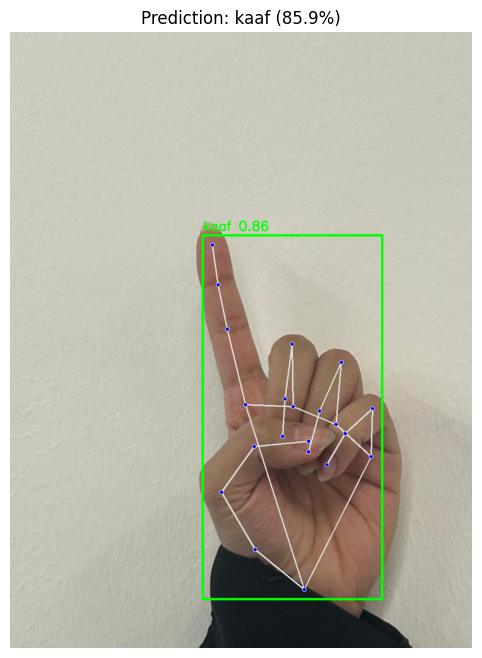


🔝 Top predictions:
  1. kaaf     → 75.21%
  2. ain      → 18.34%
  3. la       → 2.77%


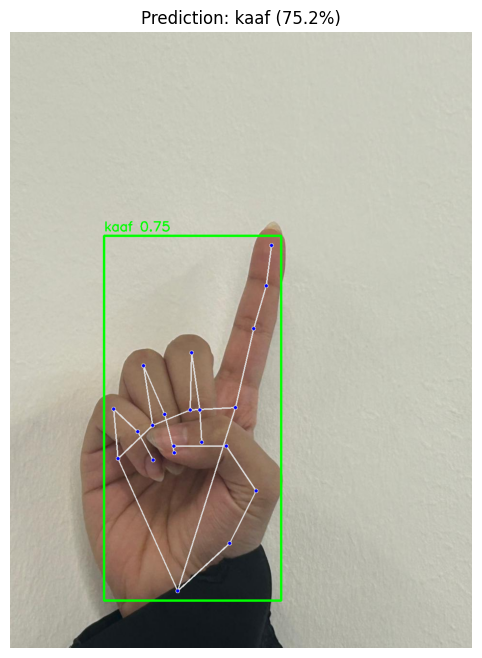

In [28]:
# ======== ARSL Detection - جاهز للاستخدام ========
import os, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from mediapipe import solutions

# ---------- 1) تحميل الموديل وأسماء الفئات ----------
MODEL_PATH   = '/content/drive/MyDrive/DSAI_Final_Project/arasl_lite.keras'
CLASSES_PATH = '/content/drive/MyDrive/DSAI_Final_Project/class_names.json'

model = load_model(MODEL_PATH)

with open(CLASSES_PATH, 'r', encoding='utf-8') as f:
    class_names = json.load(f)

print(f"✅ Loaded model | {len(class_names)} classes")

# ---------- 2) إعدادات ----------
IMG_SIZE = 160
preprocess = tf.keras.applications.efficientnet.preprocess_input  # نفس preprocessing التدريب

mp_hands   = solutions.hands
mp_drawing = solutions.drawing_utils


# ---------- 3) دالة التنبؤ ----------
def predict_image_mediapipe(image_path, top_k=3, show=True):
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ فشل قراءة الصورة: {image_path}")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    with mp_hands.Hands(static_image_mode=True,
                        max_num_hands=1,
                        min_detection_confidence=0.5) as hands:
        results = hands.process(img_rgb)

    # --- Fallback: إذا لم يكتشف يداً، صنّف الصورة كاملة ---
    if not results.multi_hand_landmarks:
        print("⚠️ لم يتم اكتشاف يد — سيتم تصنيف الصورة كاملة")
        crop = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
        crop = preprocess(np.expand_dims(crop, axis=0))
        pred = model.predict(crop, verbose=False)[0]
    else:
        hand_landmarks = results.multi_hand_landmarks[0]
        xs = [lm.x for lm in hand_landmarks.landmark]
        ys = [lm.y for lm in hand_landmarks.landmark]

        x_min = max(0, int(min(xs) * w) - 20)
        y_min = max(0, int(min(ys) * h) - 20)
        x_max = min(w, int(max(xs) * w) + 20)
        y_max = min(h, int(max(ys) * h) + 20)

        crop = img_rgb[y_min:y_max, x_min:x_max]
        if crop.size == 0:
            print("❌ Crop فارغ")
            return None

        crop_resized = cv2.resize(crop, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
        crop_input   = preprocess(np.expand_dims(crop_resized, axis=0))
        pred = model.predict(crop_input, verbose=False)[0]

        # ارسم المربع و الـ landmarks
        cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)
        mp_drawing.draw_landmarks(img_rgb, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        class_id = int(np.argmax(pred))
        conf     = float(np.max(pred))
        label    = f"{class_names[class_id]} {conf:.2f}"
        cv2.putText(img_rgb, label, (x_min, max(20, y_min - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # --- Top-K results ---
    top_idx = np.argsort(pred)[::-1][:top_k]
    print("\n🔝 Top predictions:")
    for rank, idx in enumerate(top_idx, 1):
        print(f"  {rank}. {class_names[idx]:<8} → {pred[idx]*100:.2f}%")

    if show:
        plt.figure(figsize=(8, 8))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"Prediction: {class_names[top_idx[0]]} ({pred[top_idx[0]]*100:.1f}%)")
        plt.show()

    return [(class_names[i], float(pred[i])) for i in top_idx]


# ---------- 4) اختبار على صورة واحدة ----------
predict_image_mediapipe("/content/drive/MyDrive/DSAI_Final_Project/taa1.jpeg")
predict_image_mediapipe("/content/drive/MyDrive/DSAI_Final_Project/taa2.jpeg")


# ---------- 5) (اختياري) اختبار على مجلد كامل ----------
def predict_folder(folder_path):
    exts = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    files = [f for f in os.listdir(folder_path) if f.endswith(exts)]
    print(f"📂 وُجد {len(files)} صورة\n")
    for f in files:
        print(f"\n{'='*50}\n📸 {f}\n{'='*50}")
        predict_image_mediapipe(os.path.join(folder_path, f))

# مثال:
